# Customer Churn Predictor
**Project 04 — Applied AI Engineering**

This notebook builds a machine learning system that predicts whether a telecom customer will cancel their subscription (churn).

**What makes this project different from the fraud detector:**
- The fraud detector was *unsupervised* — it learned what normal looks like without being told what fraud is
- This model is *supervised* — we show it thousands of customers with known outcomes and it learns the pattern directly
- We add **SHAP values** — these explain exactly *why* the model made each prediction, not just what it predicted

**Real world use case:**
A telecom company runs this model every night on all their customers. Any customer with a churn probability above 70% gets flagged for a retention team to call with a special offer. Without this system, they would only find out a customer was leaving when they actually cancelled.

**The model we use:** XGBoost — one of the most widely used algorithms in industry for tabular data problems like this one.

---

## Cell 1 — Imports

New libraries compared to the fraud detector:
- **xgboost** — the main model. Stands for Extreme Gradient Boosting. Builds hundreds of decision trees and combines them for a strong prediction
- **shap** — SHapley Additive exPlanations. Explains each individual prediction by showing which features contributed how much
- **LabelEncoder** — converts text categories like 'Yes'/'No' into numbers the model can understand

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import shap
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    roc_curve,
)

print('All imports OK')

All imports OK


## Cell 2 — Load and inspect the data

The Telco Customer Churn dataset from Kaggle contains 7,043 customers with 21 features each.

**Key columns:**
- `customerID` — unique identifier, not useful for prediction
- `gender`, `SeniorCitizen`, `Partner`, `Dependents` — demographic info
- `tenure` — how many months the customer has been with the company
- `PhoneService`, `InternetService`, `Contract` — what services they have
- `MonthlyCharges`, `TotalCharges` — billing info
- `Churn` — our target: Yes = customer left, No = customer stayed

Unlike the fraud dataset, these are real readable column names — no PCA anonymization here.

In [6]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

print(f'Shape: {df.shape}')
print(f'\nChurn distribution:')
print(df['Churn'].value_counts())
print(f'\nChurn rate: {(df["Churn"] == "Yes").mean() * 100:.1f}%')
print(f'\nColumn names:')
print(df.columns.tolist())
df.head()

Shape: (7043, 21)

Churn distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn rate: 26.5%

Column names:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Cell 3 — Check data quality

We check for nulls and look at the data types of each column.

One known issue with this dataset: `TotalCharges` is stored as a string (object type) instead of a number. This happens because some rows have a space instead of a value. We need to fix this before training.

In [7]:
print('Data types:')
print(df.dtypes)
print(f'\nNull values per column:')
print(df.isnull().sum())
print(f'\nTotal nulls: {df.isnull().sum().sum()}')

Data types:
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

Null values per column:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
Paperless

## Cell 4 — Visualize churn distribution

Before we clean and model the data, we visualize the key patterns.

These charts tell us which features are most associated with churn — this gives us a human-level intuition before the model confirms it mathematically:
- **Contract type** — month-to-month customers churn far more than annual contract customers
- **Tenure** — newer customers churn more than long-term customers
- **Monthly charges** — higher charges correlate with higher churn

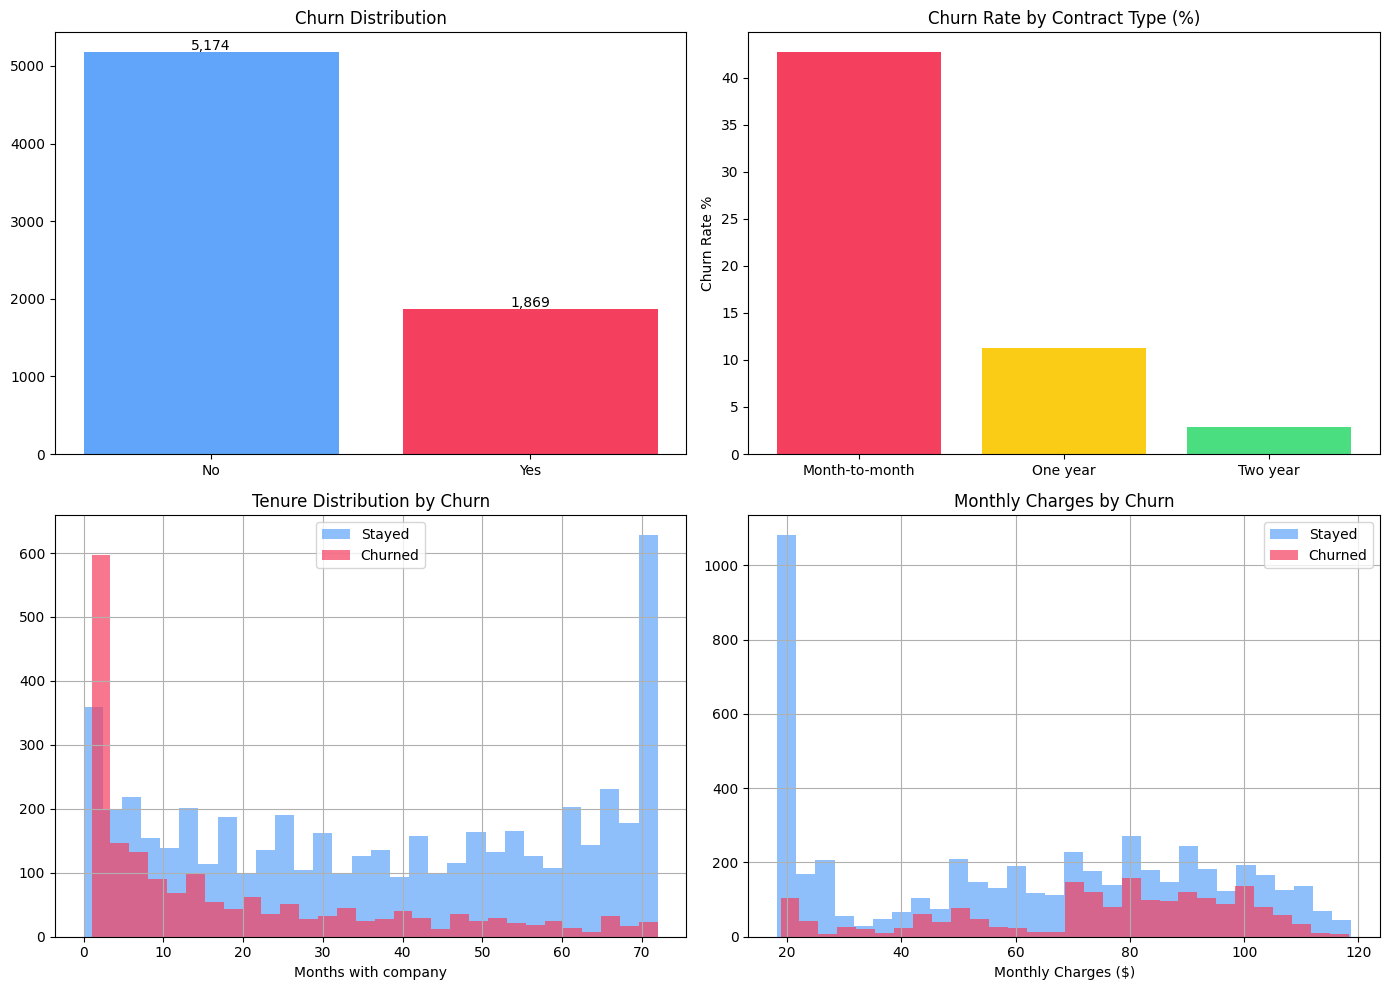

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Churn distribution
counts = df['Churn'].value_counts()
axes[0, 0].bar(counts.index, counts.values, color=['#60a5fa', '#f43f5e'])
axes[0, 0].set_title('Churn Distribution')
for i, v in enumerate(counts.values):
    axes[0, 0].text(i, v + 30, f'{v:,}', ha='center')

# Churn by contract type
contract_churn = df.groupby('Contract')['Churn'].apply(lambda x: (x == 'Yes').mean() * 100)
axes[0, 1].bar(contract_churn.index, contract_churn.values, color=['#f43f5e', '#facc15', '#4ade80'])
axes[0, 1].set_title('Churn Rate by Contract Type (%)')
axes[0, 1].set_ylabel('Churn Rate %')

# Tenure distribution by churn
df[df['Churn'] == 'No']['tenure'].hist(ax=axes[1, 0], bins=30, alpha=0.7, color='#60a5fa', label='Stayed')
df[df['Churn'] == 'Yes']['tenure'].hist(ax=axes[1, 0], bins=30, alpha=0.7, color='#f43f5e', label='Churned')
axes[1, 0].set_title('Tenure Distribution by Churn')
axes[1, 0].set_xlabel('Months with company')
axes[1, 0].legend()

# Monthly charges by churn
df[df['Churn'] == 'No']['MonthlyCharges'].hist(ax=axes[1, 1], bins=30, alpha=0.7, color='#60a5fa', label='Stayed')
df[df['Churn'] == 'Yes']['MonthlyCharges'].hist(ax=axes[1, 1], bins=30, alpha=0.7, color='#f43f5e', label='Churned')
axes[1, 1].set_title('Monthly Charges by Churn')
axes[1, 1].set_xlabel('Monthly Charges ($)')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

## Cell 5 — Data cleaning

Three cleaning steps:

1. **Fix TotalCharges** — convert from string to number. Rows with empty strings get replaced with 0
2. **Drop customerID** — a unique identifier for each customer, it has no predictive value. If we kept it the model might memorize IDs instead of learning real patterns
3. **Convert target to binary** — change 'Yes'/'No' to 1/0 so the model can work with it mathematically

In [9]:
# Fix TotalCharges — convert to numeric, replace errors with 0
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(0)

# Drop customerID — not useful for prediction
df = df.drop('customerID', axis=1)

# Convert target to binary
df['Churn'] = (df['Churn'] == 'Yes').astype(int)

print('Cleaning done.')
print(f'TotalCharges dtype: {df["TotalCharges"].dtype}')
print(f'Churn values: {df["Churn"].unique()}')
print(f'Shape: {df.shape}')

Cleaning done.
TotalCharges dtype: float64
Churn values: [0 1]
Shape: (7043, 20)


## Cell 6 — Encode categorical features

Machine learning models only understand numbers — they cannot process text like 'Male', 'Female', 'Yes', 'No', 'Month-to-month'.

We use **LabelEncoder** to convert every text column into numbers.

Examples:
- `gender`: Male → 1, Female → 0
- `Contract`: Month-to-month → 0, One year → 1, Two year → 2
- `InternetService`: DSL → 0, Fiber optic → 1, No → 2

We save the encoders in a dictionary so the API can use the exact same encoding when it receives new customer data.

In [10]:
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f'Categorical columns to encode: {categorical_cols}')

encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le

print(f'\nAll categorical columns encoded.')
print(f'Sample encoded values:')
print(df[categorical_cols].head(3))

Categorical columns to encode: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

All categorical columns encoded.
Sample encoded values:
   gender  Partner  Dependents  PhoneService  MultipleLines  InternetService  \
0       0        1           0             0              1                0   
1       1        0           0             1              0                0   
2       1        0           0             1              0                0   

   OnlineSecurity  OnlineBackup  DeviceProtection  TechSupport  StreamingTV  \
0               0             2                 0            0            0   
1               2             0                 2            0            0   
2               2             2                 0            0            0   

   StreamingMovies  Contract  Pape

## Cell 7 — Train / test split

Same approach as the fraud detector — stratified split to maintain the churn ratio in both sets.

The churn rate in this dataset is about 26% — much less extreme than the 0.17% fraud rate. This means our model has a better chance of learning from both classes, but we still use stratify to be safe.

In [11]:
X = df.drop('Churn', axis=1)
y = df['Churn']

feature_cols = X.columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f'Train size: {len(X_train):,}')
print(f'Test size:  {len(X_test):,}')
print(f'Train churn rate: {y_train.mean() * 100:.1f}%')
print(f'Test churn rate:  {y_test.mean() * 100:.1f}%')

Train size: 5,634
Test size:  1,409
Train churn rate: 26.5%
Test churn rate:  26.5%


## Cell 8 — Train XGBoost

**What is XGBoost?**

XGBoost builds hundreds of decision trees one after another. Each new tree focuses on fixing the mistakes the previous trees made. By the end, you have an ensemble of trees that together make very accurate predictions.

**Key parameters:**
- `n_estimators=300` — build 300 trees
- `max_depth=4` — each tree can be at most 4 levels deep. Deeper = more complex = more risk of overfitting
- `learning_rate=0.05` — how much each new tree corrects the previous ones. Lower = more careful learning
- `scale_pos_weight` — tells XGBoost that churned customers are rarer than non-churned. Similar to `class_weight='balanced'` in the fraud detector
- `eval_metric='auc'` — use ROC-AUC to measure performance during training

**Why XGBoost over Logistic Regression here?**
Churn involves complex non-linear relationships — a customer on a month-to-month contract with high charges AND low tenure is far more likely to churn than someone with just one of those factors. XGBoost captures these interactions automatically.

In [12]:
# Calculate class imbalance ratio
churn_ratio = (y_train == 0).sum() / (y_train == 1).sum()
print(f'Non-churn to churn ratio: {churn_ratio:.1f}:1')

model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=churn_ratio,
    eval_metric='auc',
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=50
)

print('\nXGBoost training complete.')

Non-churn to churn ratio: 2.8:1
[0]	validation_0-auc:0.82023
[50]	validation_0-auc:0.84593
[100]	validation_0-auc:0.84655
[150]	validation_0-auc:0.84585
[200]	validation_0-auc:0.84347
[250]	validation_0-auc:0.84235
[299]	validation_0-auc:0.84127

XGBoost training complete.


## Cell 9 — Evaluate the model

Same evaluation approach as the fraud detector — ROC-AUC as the primary metric, plus a full classification report.

A good churn model typically achieves ROC-AUC between 0.80 and 0.88 on this dataset. Anything above 0.85 is strong.

In [13]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

roc_auc       = roc_auc_score(y_test, y_prob)
avg_precision = average_precision_score(y_test, y_prob)

print('=' * 50)
print('CLASSIFICATION REPORT')
print('=' * 50)
print(classification_report(y_test, y_pred, target_names=['Stayed', 'Churned']))
print(f'ROC-AUC Score:     {roc_auc:.4f}')
print(f'Average Precision: {avg_precision:.4f}')

CLASSIFICATION REPORT
              precision    recall  f1-score   support

      Stayed       0.90      0.75      0.82      1035
     Churned       0.52      0.77      0.62       374

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.75      0.76      1409

ROC-AUC Score:     0.8413
Average Precision: 0.6617


## Cell 10 — Confusion matrix and ROC curve

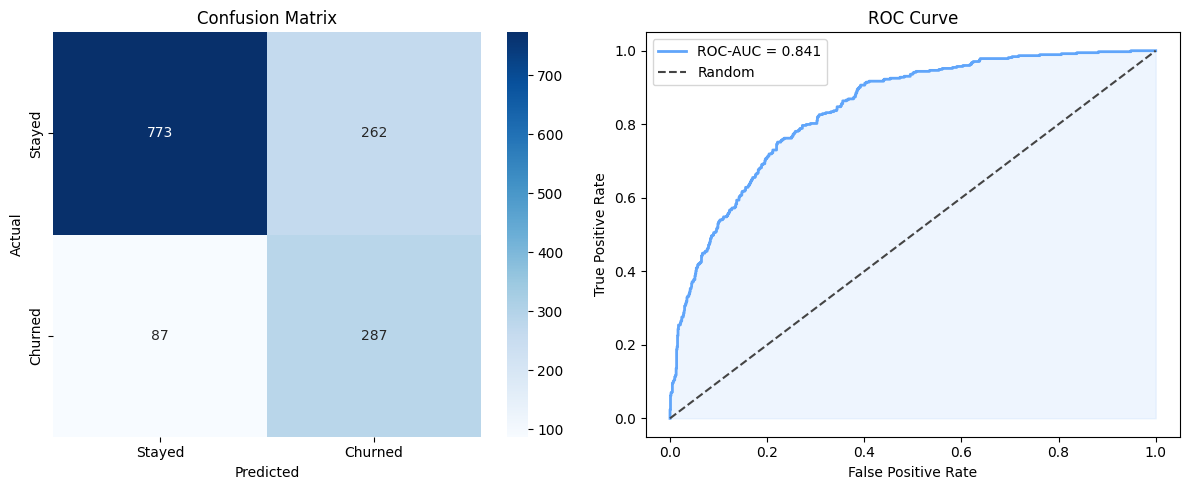

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Stayed', 'Churned'],
    yticklabels=['Stayed', 'Churned'],
    ax=axes[0]
)
axes[0].set_title('Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, color='#60a5fa', linewidth=2, label=f'ROC-AUC = {roc_auc:.3f}')
axes[1].plot([0, 1], [0, 1], color='#444', linestyle='--', label='Random')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='#60a5fa')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend()

plt.tight_layout()
plt.show()

## Cell 11 — Feature importance

XGBoost can tell us which features it found most useful for making predictions. This is a global view — across all customers, which features matter most overall.

Typically for this dataset the top features are:
- `tenure` — how long the customer has been with the company
- `Contract` — month-to-month vs annual
- `MonthlyCharges` — what they pay per month
- `TotalCharges` — total amount paid overall

This chart is global. In the next cell, SHAP gives us per-customer explanations.

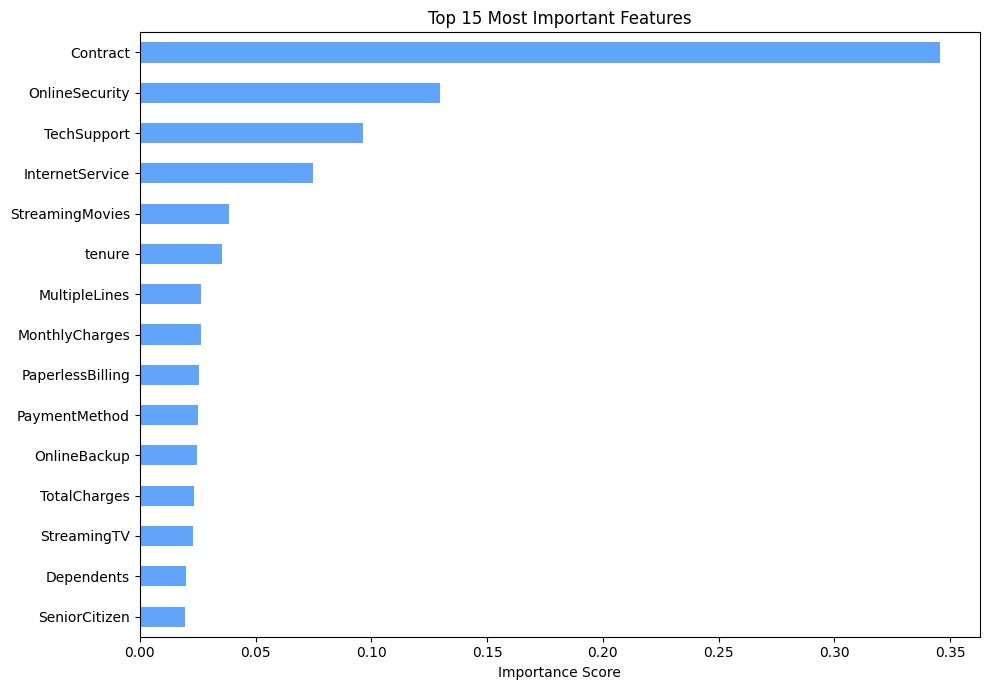

In [15]:
importance = pd.Series(model.feature_importances_, index=feature_cols)
importance = importance.sort_values(ascending=True).tail(15)

fig, ax = plt.subplots(figsize=(10, 7))
importance.plot(kind='barh', ax=ax, color='#60a5fa')
ax.set_title('Top 15 Most Important Features')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()

## Cell 12 — SHAP values

**This is what makes Project 04 stand out.**

Feature importance tells us which features matter globally across all customers. SHAP tells us exactly why the model made a specific prediction for a specific customer.

**Real example of what SHAP shows:**
```
Customer #1234 — Churn probability: 84%

Reasons pushing churn probability UP:
  + Contract = Month-to-month   (+0.34)
  + tenure = 3 months           (+0.28)
  + MonthlyCharges = $89        (+0.19)

Reasons pushing churn probability DOWN:
  - Has phone service            (-0.08)
  - Has online backup            (-0.06)
```

This is what a real retention team uses to decide how to approach a customer — not just "they will churn" but "they will churn because of their contract type and high charges, so offer them an annual contract discount."

The SHAP summary plot below shows this pattern across all customers in the test set.

SHAP Summary Plot — feature impact across all test customers


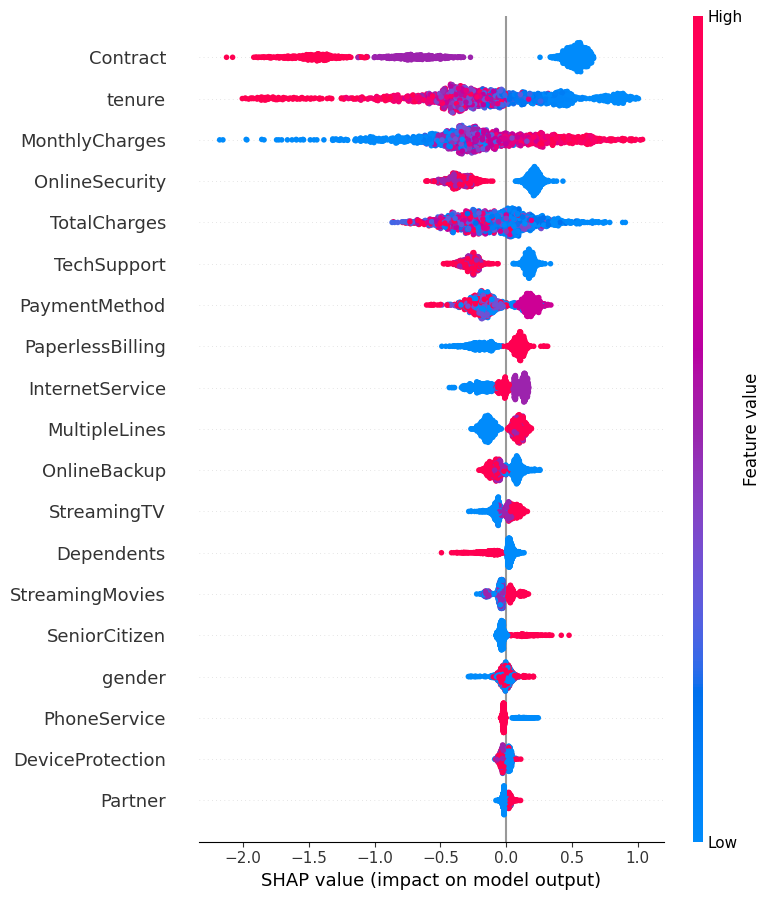

In [16]:
explainer    = shap.TreeExplainer(model)
shap_values  = explainer.shap_values(X_test)

print('SHAP Summary Plot — feature impact across all test customers')
shap.summary_plot(shap_values, X_test, feature_names=feature_cols, show=True)

## Cell 13 — SHAP for a single customer

Here we pick one specific customer from the test set and show exactly why the model predicted churn or no churn for them.

The waterfall plot shows:
- Starting from the average prediction (base value)
- Each feature pushes the prediction up (toward churn) or down (away from churn)
- The final value is the model's prediction for this specific customer

This is what you show in interviews — not just a model that works, but a model you can explain.

In [17]:
# Pick a customer the model predicted as high churn risk
high_risk_idx = np.where(y_prob > 0.7)[0]

if len(high_risk_idx) > 0:
    customer_idx = high_risk_idx[0]
    print(f'Customer index: {customer_idx}')
    print(f'Churn probability: {y_prob[customer_idx]:.1%}')
    print(f'Actual outcome: {"Churned" if y_test.iloc[customer_idx] == 1 else "Stayed"}')
    print()

    # Show top contributing features for this customer
    customer_shap = shap_values[customer_idx]
    shap_df = pd.DataFrame({
        'feature': feature_cols,
        'value': X_test.iloc[customer_idx].values,
        'shap_value': customer_shap
    }).sort_values('shap_value', key=abs, ascending=False).head(10)

    print('Top 10 factors for this customer:')
    print(shap_df.to_string(index=False))
else:
    print('No high-risk customers found in test set — try lowering the threshold')

Customer index: 1
Churn probability: 93.4%
Actual outcome: Stayed

Top 10 factors for this customer:
        feature  value  shap_value
 MonthlyCharges 100.15    0.896940
       Contract   0.00    0.562560
         tenure   8.00    0.425752
    TechSupport   2.00   -0.276274
   TotalCharges 908.55    0.210939
  PaymentMethod   1.00   -0.172446
  MultipleLines   2.00    0.159189
 OnlineSecurity   0.00    0.128480
InternetService   1.00    0.123993
  SeniorCitizen   1.00    0.123381


## Cell 14 — Save the model

We save everything the API needs:
- `model` — the trained XGBoost classifier
- `explainer` — the SHAP explainer (so the API can generate explanations for live predictions)
- `encoders` — the LabelEncoders for each categorical column (so the API encodes new data the same way)
- `feature_cols` — the exact list of features in the correct order
- Model performance metrics for display on the project page

In [18]:
model_artifacts = {
    'model':         model,
    'explainer':     explainer,
    'encoders':      encoders,
    'feature_cols':  feature_cols,
    'roc_auc':       round(roc_auc, 4),
    'avg_precision': round(avg_precision, 4),
}

with open('churn_model.pkl', 'wb') as f:
    pickle.dump(model_artifacts, f)

print('Model saved to churn_model.pkl')
print(f'  ROC-AUC:       {roc_auc:.4f}')
print(f'  Avg Precision: {avg_precision:.4f}')

Model saved to churn_model.pkl
  ROC-AUC:       0.8413
  Avg Precision: 0.6617


## Cell 15 — Sanity check

Load the saved model and score two customers — one known churner and one known loyal customer.

If churn probability for the churner >> loyalty customer, the model and save/load pipeline are both working correctly.

In [19]:
with open('churn_model.pkl', 'rb') as f:
    saved = pickle.load(f)

churn_sample  = X_test[y_test == 1].iloc[0:1]
loyal_sample  = X_test[y_test == 0].iloc[0:1]

churn_prob = saved['model'].predict_proba(churn_sample)[0][1]
loyal_prob = saved['model'].predict_proba(loyal_sample)[0][1]

print('Sanity check:')
print(f'  Known churned customer  → churn probability: {churn_prob:.4f}')
print(f'  Known loyal customer    → churn probability: {loyal_prob:.4f}')
print()
print('Model is working correctly if churned >> loyal above.')
print()
print(f'Features used: {len(saved["feature_cols"])}')
print(f'ROC-AUC: {saved["roc_auc"]}')

Sanity check:
  Known churned customer  → churn probability: 0.5930
  Known loyal customer    → churn probability: 0.0134

Model is working correctly if churned >> loyal above.

Features used: 19
ROC-AUC: 0.8413


---
## Done

`churn_model.pkl` is saved and ready for the FastAPI server.

**What this model can do that the fraud detector cannot:**
- Predict churn probability for any customer
- Explain exactly which features drove that prediction using SHAP
- Show which factors are pushing the probability up vs down

**Next step:** Build `api.py` — the FastAPI server that loads this model and serves predictions with SHAP explanations.